<center>

# ***Trabajo Práctico Nro 1 - Continual Learning***

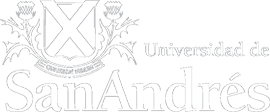

### **Asignatura:** Visión Artificial Avanzada (I309)

### **Alumnos:** Mateo Giacometti y Tiziano Leví Martín Bernal

### **Profesores:** Gastón Castro, Agustín Roca y Francisco Gómez  

### **Fecha:** 30/04/2026

</center>

---
## 0. Setup e Imports

In [1]:
# Instalar dependencias si es necesario
# !pip install torch torchvision umap-learn scikit-learn matplotlib seaborn tqdm

In [2]:
import os
import random
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset

import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.manifold import TSNE

AttributeError: module 'torch.library' has no attribute 'register_fake'

In [ ]:
# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# Crear carpeta para imágenes
os.makedirs('imgs', exist_ok=True)

---
## 1. Configuración Global

In [ ]:
# ─── Hiperparámetros globales ───────────────────────────────────────────────

CFG = {
    # Dataset
    'n_tasks': 5,
    'classes_per_task': 2,
    'n_classes_total': 10,

    # Clase a índice de tarea
    # Tarea 0: airplane(0), automobile(1)
    # Tarea 1: bird(2),     cat(3)
    # Tarea 2: deer(4),     dog(5)
    # Tarea 3: frog(6),     horse(7)
    # Tarea 4: ship(8),     truck(9)
    'task_classes': [
        [0, 1],   # Tarea 0
        [2, 3],   # Tarea 1
        [4, 5],   # Tarea 2
        [6, 7],   # Tarea 3
        [8, 9],   # Tarea 4
    ],
    'class_names': [
        'airplane', 'automobile', 'bird', 'cat', 'deer',
        'dog', 'frog', 'horse', 'ship', 'truck'
    ],

    # Entrenamiento general
    'batch_size': 256,
    'num_workers': 2,

    # Replay buffer
    'buffer_size': 200,   # muestras totales en memoria (paper Co2L usa 200)

    # Pre-entrenamiento SupCon (Etapa 2)
    'supcon_epochs': 200,
    'supcon_lr': 0.5,
    'supcon_temperature': 0.07,
    'supcon_proj_dim': 128,

    # CL - entrenamiento por tarea (Etapa 3)
    'cl_epochs': 100,
    'cl_lr': 0.5,

    # EWC
    'ewc_lambda': 100,

    # Co2L
    'co2l_lambda': 1.0,
    'co2l_distill_temp': 2.0,
}

print('Configuración cargada.')
print(f"  Tareas: {CFG['n_tasks']}")
print(f"  Clases por tarea: {CFG['classes_per_task']}")
print(f"  Buffer size: {CFG['buffer_size']} muestras")

---
## 2. Etapa 1 – Dataset, DataLoaders y Replay Buffer

### 2.1 Transformaciones

In [ ]:
# ─── Transformaciones ────────────────────────────────────────────────────────

# Normalización estándar de CIFAR-10
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2023, 0.1994, 0.2010)

# Augmentation fuerte para entrenamiento contrastivo (SupCon / Co2L)
# Basada en SimCLR / SupCon paper
transform_train_contrastive = transforms.Compose([
    transforms.RandomResizedCrop(32, scale=(0.2, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([
        transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)
    ], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

# Augmentation estándar para entrenamiento supervisado (fine-tuning, EWC, LwF)
transform_train_standard = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

# Sin augmentation para evaluación y replay buffer
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

print('Transformaciones definidas.')

### 2.2 Dataset por tarea

In [ ]:
# ─── Dataset secuencial ──────────────────────────────────────────────────────

class TaskSubset(Dataset):
    """
    Wrapper sobre un dataset de PyTorch que:
    - Filtra muestras por clases de una tarea específica.
    - Opcionalmente remapea las etiquetas al rango local [0, classes_per_task)
      (útil para Task-IL) o mantiene las etiquetas globales (para Class-IL).
    - Opcionalmente devuelve (view1, view2, label) para entrenamiento contrastivo
      usando dos transformaciones distintas.
    """

    def __init__(
        self,
        base_dataset,
        task_classes: list,
        transform=None,
        transform2=None,       # segunda vista para contrastivo
        remap_labels: bool = False,
    ):
        """
        Args:
            base_dataset : torchvision dataset sin transform (transform=None).
            task_classes : lista de etiquetas globales de esta tarea, e.g. [0, 1].
            transform    : transformación principal aplicada a cada imagen.
            transform2   : segunda transformación (solo para modo contrastivo).
            remap_labels : si True, remapea etiquetas a [0, len(task_classes)).
        """
        self.transform   = transform
        self.transform2  = transform2
        self.task_classes = task_classes
        self.remap_labels = remap_labels

        # Mapeo etiqueta global → etiqueta local
        self.label_map = {c: i for i, c in enumerate(task_classes)}

        # Filtrar índices del base_dataset
        targets = np.array(base_dataset.targets)
        mask = np.isin(targets, task_classes)
        self.indices = np.where(mask)[0]

        # Guardar datos en memoria para acceso rápido
        self.data   = base_dataset.data[self.indices]      # (N, 32, 32, 3) uint8
        self.labels = targets[self.indices].tolist()

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img   = self.data[idx]      # numpy (32, 32, 3)
        label = self.labels[idx]

        # PIL Image para las transforms de torchvision
        from PIL import Image
        img = Image.fromarray(img)

        if self.remap_labels:
            label = self.label_map[label]

        if self.transform2 is not None:
            # Modo contrastivo: devuelve dos vistas
            view1 = self.transform(img)
            view2 = self.transform2(img)
            return view1, view2, label
        else:
            img = self.transform(img) if self.transform else img
            return img, label


def get_task_loaders(
    task_id: int,
    cfg: dict,
    contrastive: bool = False,
    remap_labels: bool = False,
    data_root: str = './data',
):
    """
    Devuelve (train_loader, test_loader) para la tarea `task_id`.

    Args:
        task_id      : índice de tarea (0-indexed).
        cfg          : diccionario de configuración global.
        contrastive  : si True, el train_loader devuelve dos vistas por muestra.
        remap_labels : si True, usa etiquetas locales [0, classes_per_task).
        data_root    : carpeta donde se descarga CIFAR-10.
    """
    task_classes = cfg['task_classes'][task_id]

    # Descargar CIFAR-10 sin transform (lo aplicamos en TaskSubset)
    base_train = torchvision.datasets.CIFAR10(
        root=data_root, train=True,  download=True, transform=None
    )
    base_test = torchvision.datasets.CIFAR10(
        root=data_root, train=False, download=True, transform=None
    )

    if contrastive:
        train_ds = TaskSubset(
            base_train, task_classes,
            transform=transform_train_contrastive,
            transform2=transform_train_contrastive,
            remap_labels=remap_labels,
        )
    else:
        train_ds = TaskSubset(
            base_train, task_classes,
            transform=transform_train_standard,
            remap_labels=remap_labels,
        )

    test_ds = TaskSubset(
        base_test, task_classes,
        transform=transform_test,
        remap_labels=remap_labels,
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=cfg['batch_size'],
        shuffle=True,
        num_workers=cfg['num_workers'],
        pin_memory=True,
        drop_last=True,
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=cfg['batch_size'],
        shuffle=False,
        num_workers=cfg['num_workers'],
        pin_memory=True,
    )

    return train_loader, test_loader


print('TaskSubset y get_task_loaders definidos.')

### 2.3 Verificación del dataset

In [ ]:
# ─── Verificación rápida ─────────────────────────────────────────────────────

print('Verificando partición de tareas:\n')
print(f"{'Tarea':>5}  {'Clases':<25}  {'Train':>6}  {'Test':>6}")
print('-' * 50)

for t in range(CFG['n_tasks']):
    train_loader, test_loader = get_task_loaders(t, CFG, contrastive=False)
    names = [CFG['class_names'][c] for c in CFG['task_classes'][t]]
    n_train = len(train_loader.dataset)
    n_test  = len(test_loader.dataset)
    print(f"  {t:>3}  {str(names):<25}  {n_train:>6}  {n_test:>6}")

print('\n✓ Verificación completada.')

### 2.4 Replay Buffer con Reservoir Sampling

In [ ]:
# ─── Replay Buffer ───────────────────────────────────────────────────────────

class ReplayBuffer:
    """
    Buffer de memoria de tamaño fijo con política de Reservoir Sampling.

    Reservoir Sampling garantiza que, al final de ver N muestras, cada
    muestra tiene probabilidad buffer_size/N de estar en el buffer.
    Esto produce una distribución uniforme sobre todas las muestras vistas,
    sin sesgo hacia las tareas más recientes.

    Internamente almacena tensores en CPU para no saturar la GPU.
    """

    def __init__(self, buffer_size: int):
        self.buffer_size = buffer_size
        self.n_seen = 0          # total de muestras vistas (para reservoir)

        # Almacenamiento (inicialmente vacío)
        self.images  = None      # Tensor (buffer_size, C, H, W)
        self.labels  = None      # Tensor (buffer_size,)
        self.task_ids = None     # Tensor (buffer_size,)  — útil para Task-IL
        self.current_size = 0

    # ── Adición de muestras ───────────────────────────────────────────────────

    def add_from_loader(self, loader: DataLoader, task_id: int):
        """
        Recorre el loader y añade muestras al buffer con reservoir sampling.
        Llámalo al FINAL del entrenamiento de cada tarea.

        Args:
            loader  : DataLoader de la tarea (modo estándar, no contrastivo).
            task_id : índice de la tarea (0-indexed).
        """
        for imgs, labels in loader:
            # imgs: (B, C, H, W)  labels: (B,)
            for i in range(imgs.size(0)):
                self._reservoir_update(
                    imgs[i].cpu(),
                    labels[i].item(),
                    task_id,
                )

    def _reservoir_update(self, img: torch.Tensor, label: int, task_id: int):
        """
        Actualiza el buffer con una sola muestra usando reservoir sampling.
        """
        self.n_seen += 1

        if self.current_size < self.buffer_size:
            # Buffer aún no lleno: agregar directamente
            idx = self.current_size
            self._set_sample(idx, img, label, task_id)
            self.current_size += 1

        else:
            # Buffer lleno: reemplazar con probabilidad buffer_size / n_seen
            j = random.randint(0, self.n_seen - 1)
            if j < self.buffer_size:
                self._set_sample(j, img, label, task_id)

    def _set_sample(self, idx: int, img: torch.Tensor, label: int, task_id: int):
        """Escribe una muestra en la posición `idx` del buffer."""
        if self.images is None:
            # Inicializar tensores la primera vez
            C, H, W = img.shape
            self.images   = torch.zeros(self.buffer_size, C, H, W)
            self.labels   = torch.zeros(self.buffer_size, dtype=torch.long)
            self.task_ids = torch.zeros(self.buffer_size, dtype=torch.long)

        self.images[idx]   = img
        self.labels[idx]   = label
        self.task_ids[idx] = task_id

    # ── Sampling ──────────────────────────────────────────────────────────────

    def sample(self, n: int, device=None):
        """
        Extrae `n` muestras aleatorias del buffer.

        Returns:
            imgs      : Tensor (n, C, H, W)
            labels    : Tensor (n,)
            task_ids  : Tensor (n,)
        """
        if self.current_size == 0:
            raise RuntimeError('El buffer está vacío.')

        n = min(n, self.current_size)
        idx = torch.randperm(self.current_size)[:n]

        imgs     = self.images[:self.current_size][idx]
        labels   = self.labels[:self.current_size][idx]
        task_ids = self.task_ids[:self.current_size][idx]

        if device is not None:
            imgs, labels, task_ids = (
                imgs.to(device),
                labels.to(device),
                task_ids.to(device),
            )

        return imgs, labels, task_ids

    def get_loader(self, batch_size: int, transform=None):
        """
        Devuelve un DataLoader con todas las muestras del buffer.
        Útil para calcular la Fisher Information (EWC) o distilación.

        Args:
            batch_size : tamaño del batch.
            transform  : transformación opcional a aplicar sobre las imágenes.
        """
        if self.current_size == 0:
            raise RuntimeError('El buffer está vacío.')

        dataset = BufferDataset(
            self.images[:self.current_size],
            self.labels[:self.current_size],
            self.task_ids[:self.current_size],
            transform=transform,
        )
        return DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # ── Información ───────────────────────────────────────────────────────────

    def __len__(self):
        return self.current_size

    def __repr__(self):
        return (
            f'ReplayBuffer(capacity={self.buffer_size}, '
            f'used={self.current_size}, '
            f'seen={self.n_seen})'
        )


class BufferDataset(Dataset):
    """Dataset auxiliar que envuelve los tensores del ReplayBuffer."""

    def __init__(self, images, labels, task_ids, transform=None):
        self.images   = images
        self.labels   = labels
        self.task_ids = task_ids
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img      = self.images[idx]
        label    = self.labels[idx]
        task_id  = self.task_ids[idx]

        if self.transform is not None:
            from PIL import Image
            # Denormalizar y convertir a PIL para aplicar transform
            img_np = img.permute(1, 2, 0).numpy()
            mean = np.array(CIFAR10_MEAN)
            std  = np.array(CIFAR10_STD)
            img_np = np.clip(img_np * std + mean, 0, 1)
            img_pil = Image.fromarray((img_np * 255).astype(np.uint8))
            img = self.transform(img_pil)

        return img, label, task_id


print('ReplayBuffer y BufferDataset definidos.')

### 2.5 Verificación del Replay Buffer

In [ ]:
# ─── Test del ReplayBuffer ───────────────────────────────────────────────────

print('=== Test del ReplayBuffer ===')

buffer = ReplayBuffer(buffer_size=CFG['buffer_size'])

# Simular el llenado del buffer con las primeras 3 tareas
for task_id in range(3):
    train_loader, _ = get_task_loaders(task_id, CFG, contrastive=False)
    buffer.add_from_loader(train_loader, task_id)
    print(f'  Después de tarea {task_id}: {buffer}')

# Verificar distribución de clases en el buffer
all_labels   = buffer.labels[:buffer.current_size].numpy()
all_task_ids = buffer.task_ids[:buffer.current_size].numpy()

print(f'\nDistribución de muestras por tarea en el buffer:')
for t in range(3):
    count = (all_task_ids == t).sum()
    pct   = 100 * count / buffer.current_size
    print(f'  Tarea {t}: {count:>3} muestras ({pct:.1f}%)')

print(f'\nDistribución de muestras por clase en el buffer:')
for c in range(6):  # clases 0-5 (tareas 0, 1, 2)
    count = (all_labels == c).sum()
    print(f'  Clase {c} ({CFG["class_names"][c]:>12}): {count:>3} muestras')

# Test de sampling
imgs_sample, labels_sample, task_ids_sample = buffer.sample(32, device=DEVICE)
print(f'\nSampling: imgs={imgs_sample.shape}, labels={labels_sample.shape}')

# Visualización de muestras del buffer
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
mean = torch.tensor(CIFAR10_MEAN).view(3, 1, 1)
std  = torch.tensor(CIFAR10_STD).view(3, 1, 1)

imgs_cpu = imgs_sample[:16].cpu() * std + mean   # denormalizar
imgs_cpu = imgs_cpu.clamp(0, 1)

for i, ax in enumerate(axes.flat):
    ax.imshow(imgs_cpu[i].permute(1, 2, 0).numpy())
    lbl = labels_sample[i].item()
    tid = task_ids_sample[i].item()
    ax.set_title(f'{CFG["class_names"][lbl]}\n(t={tid})', fontsize=7)
    ax.axis('off')

plt.suptitle('Muestras del Replay Buffer (16 de 32 sampleadas)', fontsize=12)
plt.tight_layout()
plt.savefig('imgs/replay_buffer_samples.png', dpi=120, bbox_inches='tight')
plt.show()
print('\n✓ Buffer verificado y guardado en imgs/replay_buffer_samples.png')